# ML Astronomy

## Imports

In [23]:
import os
import math

import kagglehub
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

## Dataset loading

In [2]:
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")
filename = "star_classification.csv"
filepath = os.path.join(path, filename)
df = pl.read_csv(filepath, schema_overrides={"obj_ID": pl.Utf8})

## EDA

### Dataset analysis

In [11]:
df.head()

obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
str,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,str,f64,i64,i64,i64
"""1237660961327743232""",135.689107,32.494632,23.87882,22.2753,20.39501,19.16573,18.79371,3606,301,2,79,6.5438e18,"""GALAXY""",0.6347936,5812,56354,171
"""1237664879951151360""",144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.1760e19,"""GALAXY""",0.779136,10445,58158,427
"""1237660961330430208""",142.18879,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.1522e18,"""GALAXY""",0.6441945,4576,55592,299
"""1237663478724297984""",338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.2501,4192,301,3,214,1.0301e19,"""GALAXY""",0.9323456,9149,58039,775
"""1237680272041378048""",345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.8919e18,"""GALAXY""",0.1161227,6121,56187,842


In [19]:
df.schema

Schema([('obj_ID', String),
        ('alpha', Float64),
        ('delta', Float64),
        ('u', Float64),
        ('g', Float64),
        ('r', Float64),
        ('i', Float64),
        ('z', Float64),
        ('run_ID', Int64),
        ('rerun_ID', Int64),
        ('cam_col', Int64),
        ('field_ID', Int64),
        ('spec_obj_ID', Float64),
        ('class', String),
        ('redshift', Float64),
        ('plate', Int64),
        ('MJD', Int64),
        ('fiber_ID', Int64)])

In [16]:
print(f"Lines: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Lines: 100000
Columns: 18


In [18]:
df.describe()

statistic,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64
"""count""","""100000""",100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,"""100000""",100000.0,100000.0,100000.0,100000.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0
"""mean""",null,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.66881,4481.36606,301.0,3.51161,186.13052,5.7839e18,null,0.576661,5137.00966,55588.6475,449.31274
"""std""",null,96.502241,19.644665,31.769291,31.750292,1.85476,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.3240e18,null,0.730707,2952.303351,1808.484233,272.498404
"""min""","""1.237646794381e+18""",0.005528,-18.785328,-9999.0,-9999.0,9.82207,9.469903,-9999.0,109.0,301.0,1.0,11.0,2.9952e17,"""GALAXY""",-0.009971,266.0,51608.0,1.0
"""25%""",null,127.518745,5.146822,20.35237,18.96523,18.13586,17.73229,17.46069,3187.0,301.0,2.0,82.0,2.8441e18,null,0.054517,2526.0,54234.0,221.0
"""50%""",null,180.900873,23.646462,22.17914,21.09993,20.12531,19.40515,19.0046,4188.0,301.0,4.0,146.0,5.6149e18,null,0.4241756,4987.0,55869.0,433.0
"""75%""",null,233.895005,39.901518,23.6874,22.12376,21.04478,20.39648,19.92112,5326.0,301.0,5.0,241.0,8.3319e18,null,0.7041366,7400.0,56777.0,645.0
"""max""","""1237680531356386304""",359.99981,83.000519,32.78139,31.60224,29.57186,32.14147,29.38374,8162.0,301.0,6.0,989.0,1.4127e19,"""STAR""",7.011245,12547.0,58932.0,1000.0


### Target distribution

shape: (3, 2)
┌────────┬───────┐
│ class  ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ STAR   ┆ 21594 │
│ QSO    ┆ 18961 │
│ GALAXY ┆ 59445 │
└────────┴───────┘


<Axes: xlabel='class', ylabel='count'>

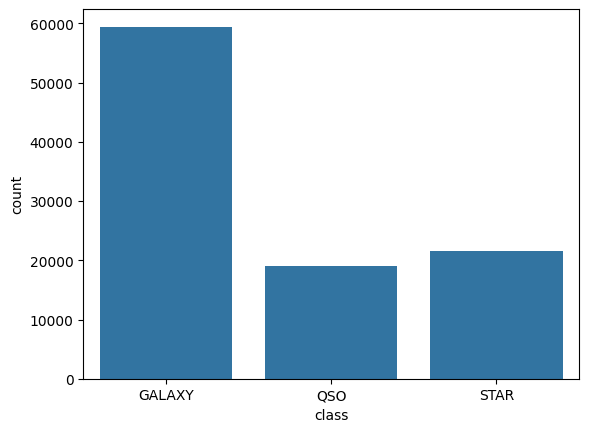

In [18]:
print(df["class"].value_counts())
sns.countplot(data=df, x="class")

### Missing values

In [21]:
df.to_pandas().isna().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

### Numeric distribution

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'delta'}>, <Axes: title={'center': 'u'}>,
        <Axes: title={'center': 'g'}>],
       [<Axes: title={'center': 'r'}>, <Axes: title={'center': 'i'}>,
        <Axes: title={'center': 'z'}>,
        <Axes: title={'center': 'run_ID'}>],
       [<Axes: title={'center': 'rerun_ID'}>,
        <Axes: title={'center': 'cam_col'}>,
        <Axes: title={'center': 'field_ID'}>,
        <Axes: title={'center': 'spec_obj_ID'}>],
       [<Axes: title={'center': 'redshift'}>,
        <Axes: title={'center': 'plate'}>,
        <Axes: title={'center': 'MJD'}>,
        <Axes: title={'center': 'fiber_ID'}>]], dtype=object)

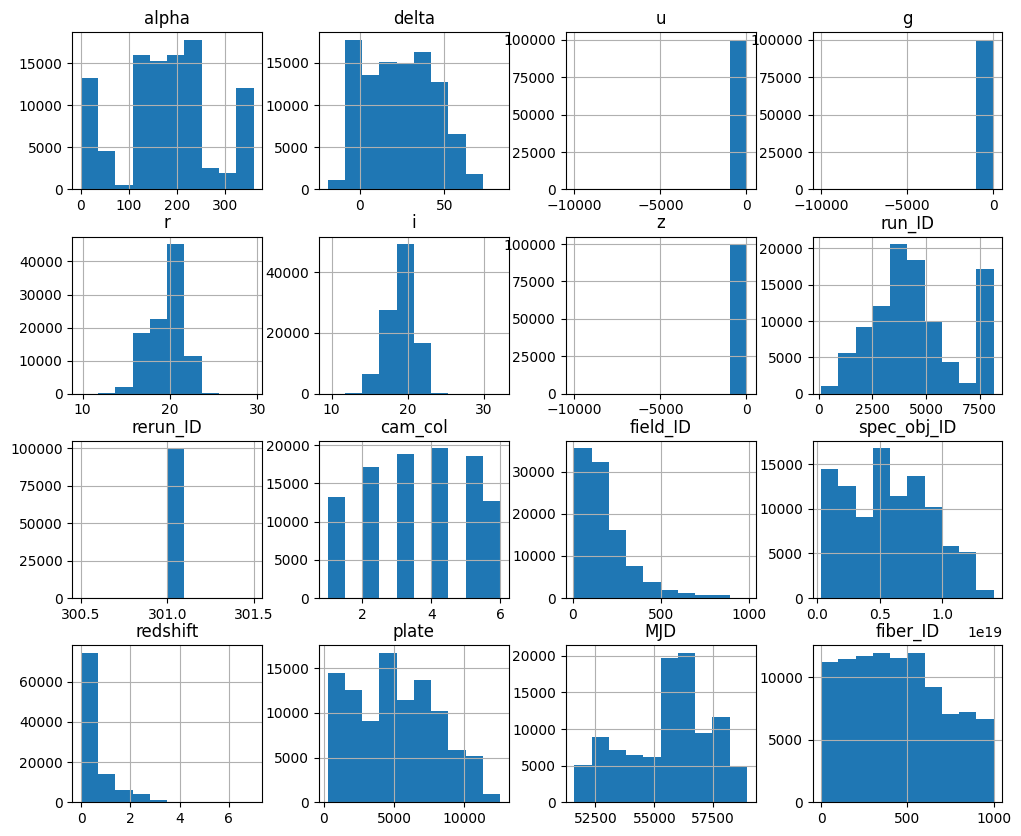

In [3]:
df.to_pandas().hist(figsize=(12, 10))

### Comparison with the target

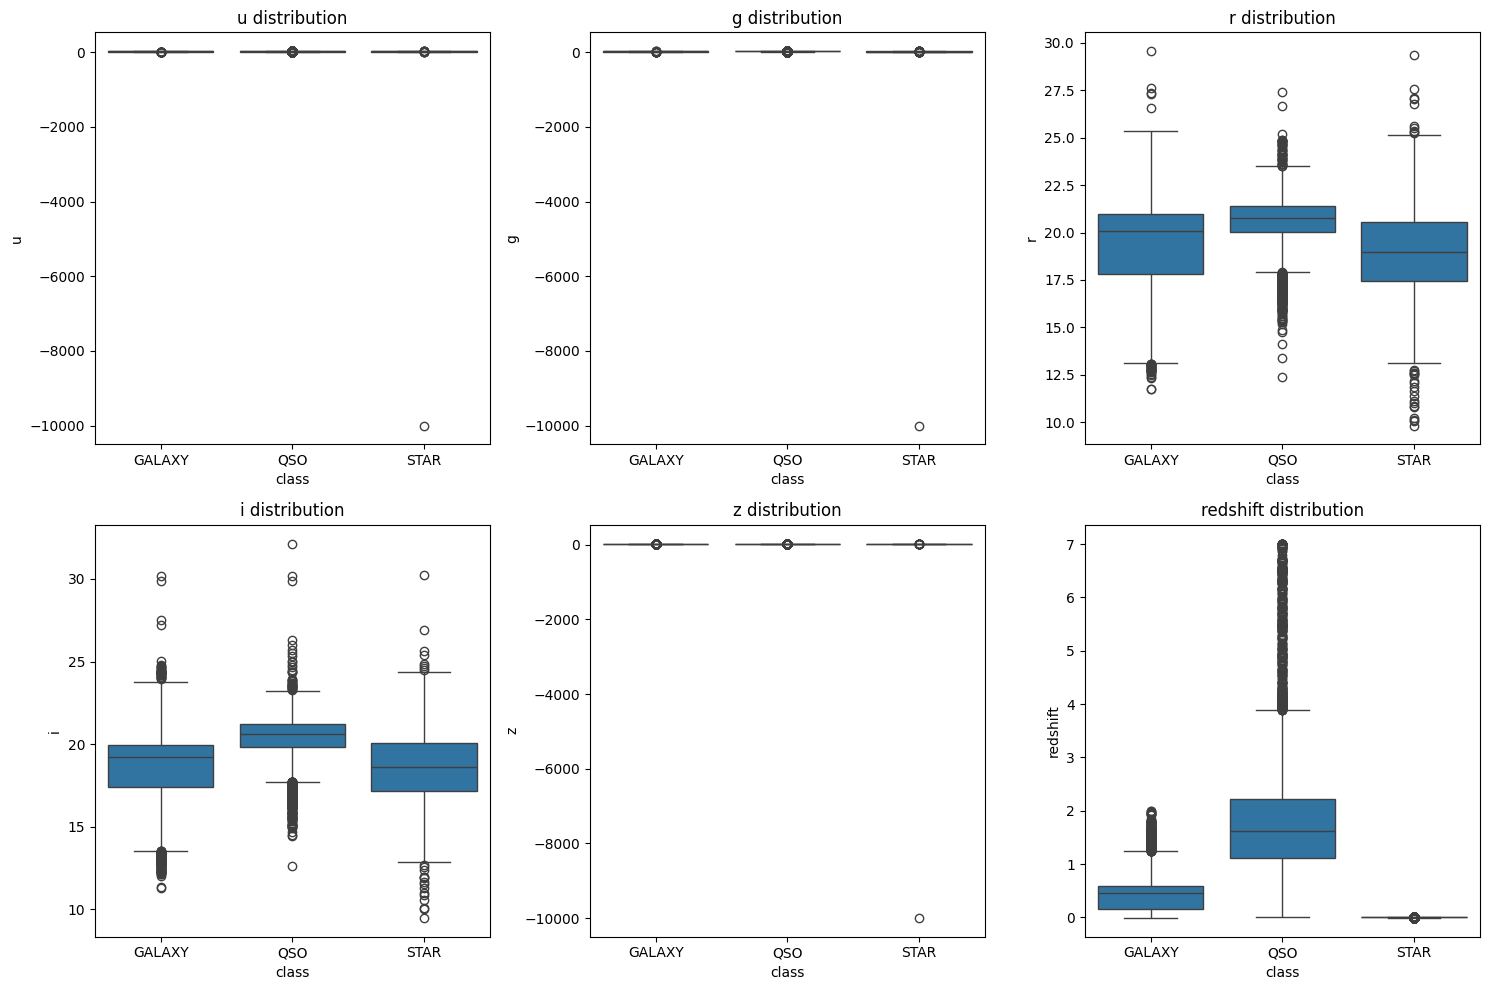

In [30]:
columns = ["u", "g", "r", "i", "z", "redshift"]

n_cols = 3
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

idx = 0
for i in range(n_rows):
    for j in range(n_cols):
        col = columns[idx]
        sns.boxplot(data=df, x="class", y=col, ax=axes[i, j])
        axes[i, j].set_title(f"{col} distribution")
        idx += 1

plt.tight_layout()
plt.show()

### Correlation

<Axes: >

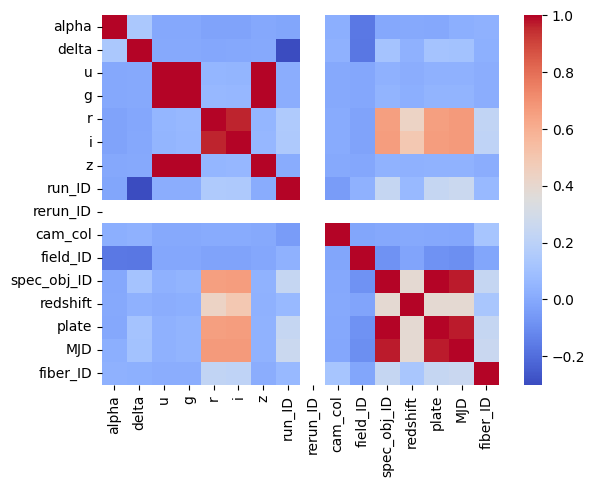

In [27]:
corr = df.to_pandas().corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")

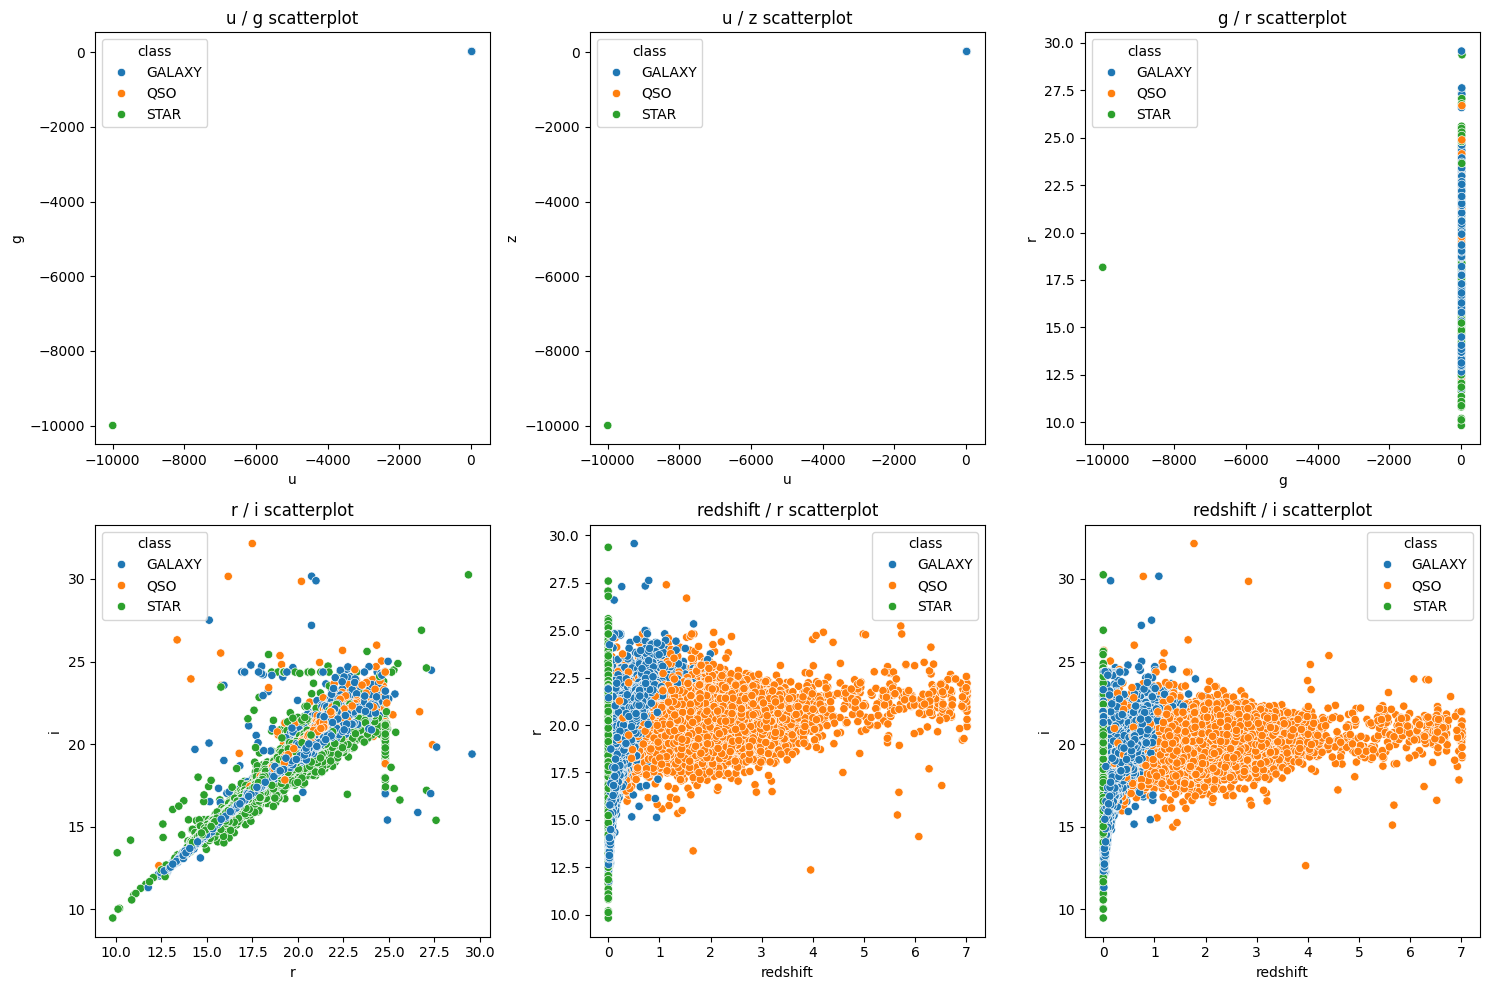

In [41]:
columns = [ ["u", "g"], ["u", "z"], ["g", "r"], ["r", "i"], ["redshift", "r"], ["redshift", "i"] ]

n_cols = 3
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

idx = 0
for i in range(n_rows):
    for j in range(n_cols):
        if idx < len(columns):
            cols = columns[idx]
            sns.scatterplot(data=df, x=cols[0], y=cols[1], hue="class", ax=axes[i, j])
            axes[i, j].set_title(f"{cols[0]} / {cols[1]} scatterplot")
            idx += 1

plt.tight_layout()
plt.show()


## Train and test split

## Preprocessing

## Models selection

## Model evaluation